In [46]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/merged_dataset_organized_45photic.csv')
df

,ORD_OCC,CAST_ID,DATE_TIME_UTC,DATE_TIME_PST,LAT_DEC,LON_DEC,STA_ID,LINE,STA,DEPTH,...,Lat_Dec,Lon_Dec,Ac_Line,Bottom_D,Secchi,IntChl,IntC14,TimeZone,Visibility,PHOTIC_ZONE
0,1.0,9308_001d,1993-08-11T12:05:46Z,1993-08-11T04:05:46Z,NaN,NaN,093.3 026.7,93.3,26.7,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,1.0,9308_001d,1993-08-11T12:06:04Z,1993-08-11T04:06:04Z,-99.00000,-99.00000,093.3 026.7,93.3,26.7,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,1.0,9308_001d,1993-08-11T12:06:10Z,1993-08-11T04:06:10Z,-99.00000,-99.00000,093.3 026.7,93.3,26.7,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,1.0,9308_001d,1993-08-11T12:06:11Z,1993-08-11T04:06:11Z,-99.00000,-99.00000,093.3 026.7,93.3,26.7,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,1.0,9308_001d,1993-08-11T12:06:14Z,1993-08-11T04:06:14Z,-99.00000,-99.00000,093.3 026.7,93.3,26.7,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255961,11.0,2101_011d,2021-01-17T18:44:19Z,2021-01-17T10:44:19Z,31.84200,-119.55928,093.3 060.0,93.3,60.0,516.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1255962,11.0,2101_011d,2021-01-17T18:44:23Z,2021-01-17T10:44:23Z,31.84199,-119.55927,093.3 060.0,93.3,60.0,517.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1255963,11.0,2101_011d,2021-01-17T18:44:29Z,2021-01-17T10:44:29Z,31.84198,-119.55926,093.3 060.0,93.3,60.0,518.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1255964,11.0,2101_011d,2021-01-17T18:44:30Z,2021-01-17T10:44:30Z,31.84198,-119.55926,093.3 060.0,93.3,60.0,519.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


## Create a correlation matrix between variables in the dataset (from Secchi and Par datasets)

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data/merged_dataset_organized_45photic.csv')


# Extract Secchi per cast

secchi_per_cast = (
    df[['CAST_COUNT', 'Secchi']]
    .dropna()
    .drop_duplicates('CAST_COUNT')
)


# Keep only rows at photic_zone (4.5% of light reaches)
photic_unique = df[df['PHOTIC_ZONE'] == True].copy()

# Confirm one row per cast
print("Rows:", len(photic_unique))
print("Unique CAST_COUNT:", photic_unique['CAST_COUNT'].nunique())


# Merge Secchi back in
photic_unique = photic_unique.merge(
    secchi_per_cast,
    on='CAST_COUNT',
    how='left',
    suffixes=('', '_cast')
)

# Replace Secchi column
photic_unique['Secchi'] = photic_unique['Secchi_cast']


# Variables to test correlation with Secchi depth

vars_to_test = [
    'DEPTH',
    'PRESSURE',
    'ESTCHL_CRUISECORR',
    'ESTCHL_STACORR',
    'BAT',
    'XMISS',
    'SPAR',
    'PAR',
    'CHL_A',
    'PHAEO',
    'Distance',
    'Bottom_D',
    'Secchi',
    'IntChl',
    'IntC14',
    'Visibility'
]

# Convert to numeric 
photic_unique[vars_to_test] = photic_unique[vars_to_test].apply(
    pd.to_numeric, errors='coerce'
)


# Compute Correlation
corr_matrix = photic_unique[vars_to_test].corr(method='pearson')

print(corr_matrix[['Secchi']].sort_values(by='Secchi', ascending=False))


Rows: 1970
Unique CAST_COUNT: 1970
                     Secchi
Secchi             1.000000
DEPTH              0.730981
PRESSURE           0.730938
PAR                0.101651
XMISS              0.030247
BAT               -0.034866
SPAR              -0.073225
ESTCHL_CRUISECORR -0.203751
ESTCHL_STACORR    -0.397032
CHL_A             -0.430859
PHAEO             -0.464594
Distance                NaN
Bottom_D                NaN
IntChl                  NaN
IntC14                  NaN
Visibility              NaN


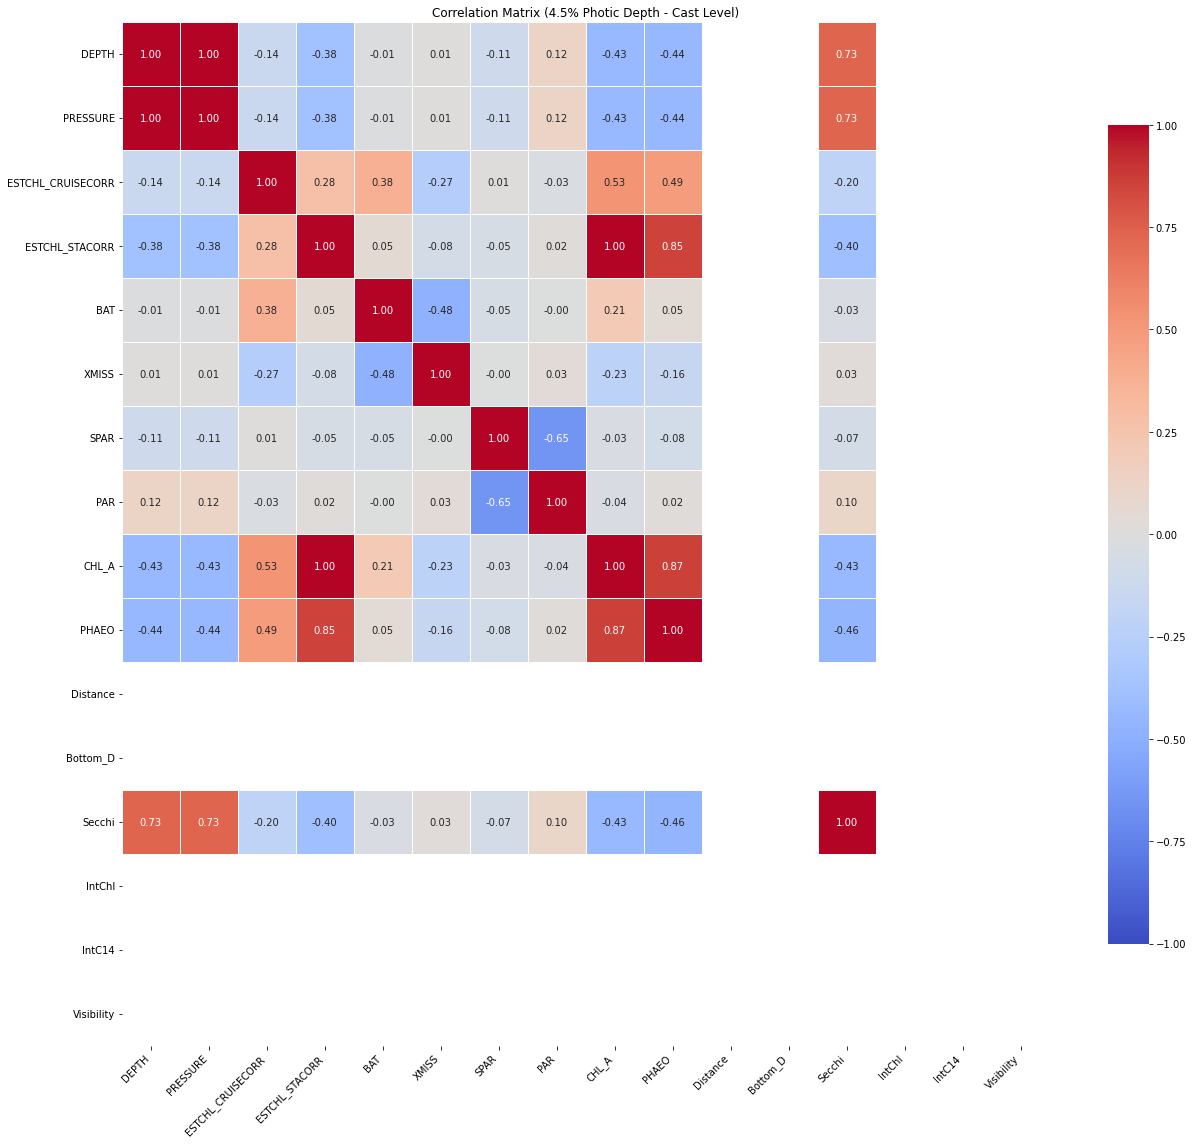

In [21]:
plt.figure(figsize=(18, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Matrix (4.5% Photic Depth - Cast Level)')
plt.tight_layout()
plt.show()


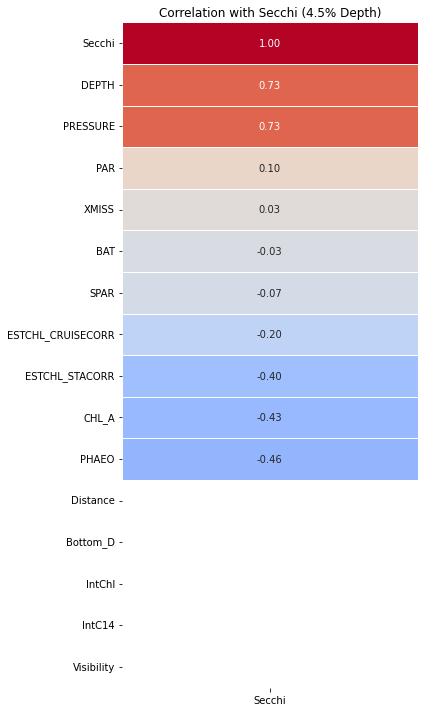

In [ ]:
# Correlation with Secchi only
secchi_corr = corr_matrix[['Secchi']].sort_values(
    by='Secchi',
    ascending=False
)

plt.figure(figsize=(6,10))

sns.heatmap(
    secchi_corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar=False
)

plt.title('Correlation with Secchi (4.5% Depth)')
plt.tight_layout()
plt.show()


## General Additive Models

### Create scatterplots of variables to determine appropriate functions

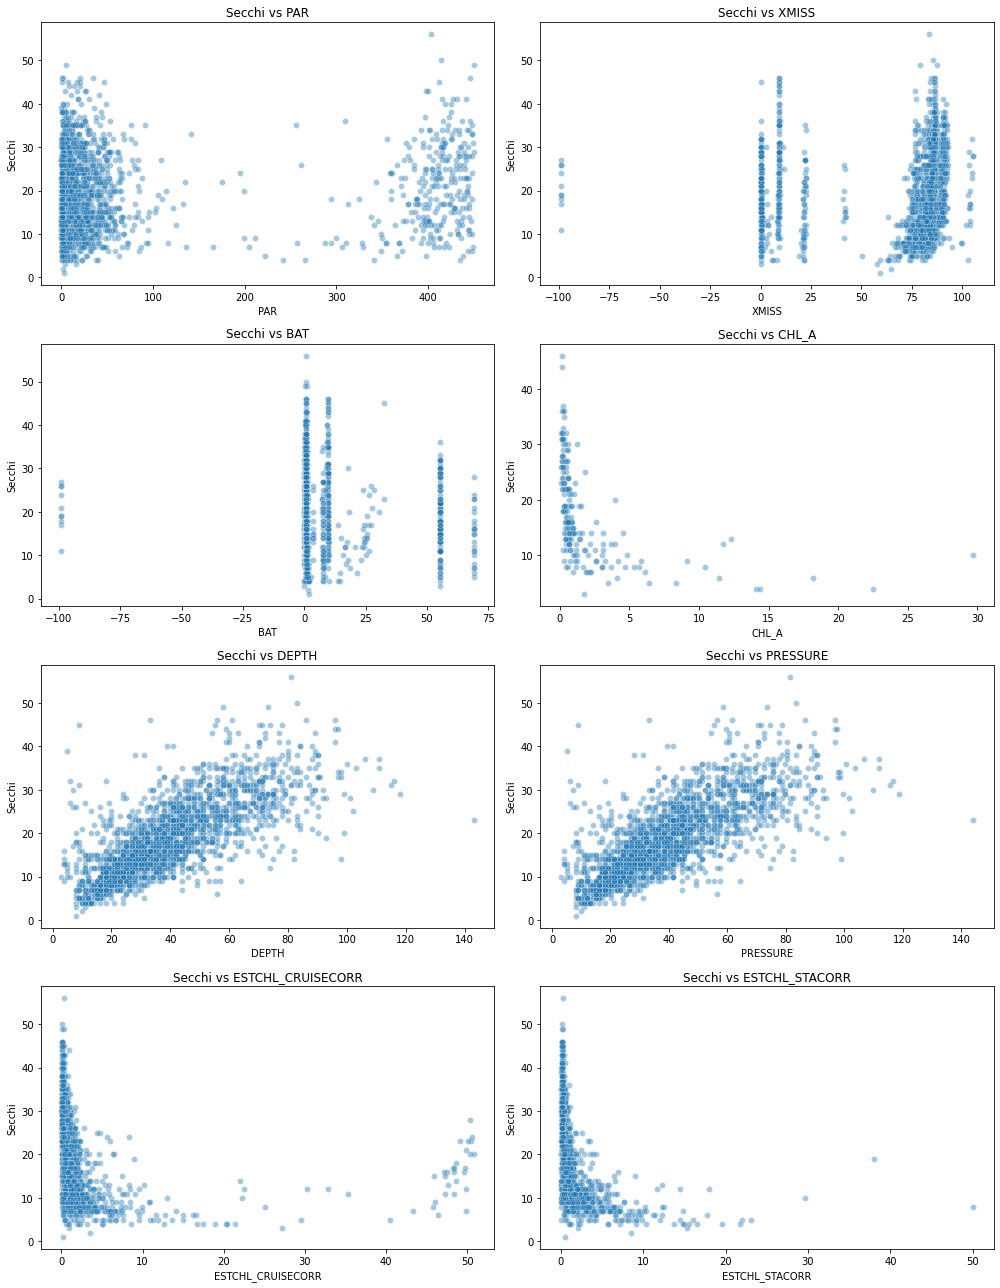

<Figure size 432x288 with 0 Axes>

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    'PAR',
    'XMISS',
    'BAT',
    'CHL_A',
    'DEPTH',
    'PRESSURE',
    'ESTCHL_CRUISECORR',
    'ESTCHL_STACORR'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.scatterplot(
        x=var,
        y='Secchi',
        data=photic_unique,
        alpha=0.4,
        ax=axes[i]
    )
    axes[i].set_title(f'Secchi vs {var}')

plt.tight_layout()
plt.show()

plt.savefig("secchi_vs_parscatterplots.png", dpi=300, bbox_inches='tight')

plt.show()


DEPTH and PRESSURE (from PAR) and Secchi have a stronger linear relationship. Excluded since it's related to secchi disk measurements.
XMISS has somewhat positive relationship.
BAT is monotonic negative.
CHL_A, ESTCHL_CRUISECORR, and ESTCHL_STACORR seems to be exponentially decaying.

Model 1: Secchi s(XMISS)

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from pygam import LinearGAM, s
import numpy as np

df1 = photic_unique[['XMISS', 'Secchi']].dropna()

X1 = df1[['XMISS']].values
y1 = df1['Secchi'].values

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=42
)

gam_xmiss = LinearGAM(s(0, n_splines=10)).fit(X1_train, y1_train)

y1_pred = gam_xmiss.predict(X1_test)

print("MODEL 1: Secchi ~ s(XMISS)")
print("R²:", r2_score(y1_test, y1_pred))
print("RMSE:", np.sqrt(mean_squared_error(y1_test, y1_pred)))



MODEL 1: Secchi ~ s(XMISS)
R²: 0.14526820845335808
RMSE: 8.230158816809114


Model 2: Secchi ~ s(BAT)

In [54]:
df2 = photic_unique[['BAT', 'Secchi']].dropna()

X2 = df2[['BAT']].values
y2 = df2['Secchi'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

gam_bat = LinearGAM(s(0, n_splines=8)).fit(X2_train, y2_train)

y2_pred = gam_bat.predict(X2_test)

print("\nMODEL 2: Secchi ~ s(BAT)")
print("R²:", r2_score(y2_test, y2_pred))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, y2_pred)))




MODEL 2: Secchi ~ s(BAT)
R²: 0.001127447016946892
RMSE: 8.897097028450066


Model 3: Secchi ~ s(PAR)

In [55]:
df3 = photic_unique[['PAR', 'Secchi']].dropna()

X3 = df3[['PAR']].values
y3 = df3['Secchi'].values

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.3, random_state=42
)

gam_par = LinearGAM(s(0, n_splines=8)).fit(X3_train, y3_train)

y3_pred = gam_par.predict(X3_test)

print("\nMODEL 3: Secchi ~ s(PAR)")
print("R²:", r2_score(y3_test, y3_pred))
print("RMSE:", np.sqrt(mean_squared_error(y3_test, y3_pred)))




MODEL 3: Secchi ~ s(PAR)
R²: -0.0016564452110328087
RMSE: 8.909486659887632


Model 4: Secchi ~ s(XMISS) + s(log_CHL_A)

In [56]:
df4 = photic_unique[['XMISS', 'CHL_A', 'Secchi']].dropna().copy()
df4['log_CHL_A'] = np.log1p(df4['CHL_A']) #Log transform CHL_A to reduce skewness

X4 = df4[['XMISS', 'log_CHL_A']].values
y4 = df4['Secchi'].values

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.3, random_state=42
)

gam_opt_bio = LinearGAM(
    s(0, n_splines=10) +  # XMISS
    s(1, n_splines=8)     # log_CHL_A
).fit(X4_train, y4_train)

y4_pred = gam_opt_bio.predict(X4_test)

print("\nMODEL 4: Secchi ~ s(XMISS) + s(log_CHL_A)")
print("R²:", r2_score(y4_test, y4_pred))
print("RMSE:", np.sqrt(mean_squared_error(y4_test, y4_pred)))



MODEL 4: Secchi ~ s(XMISS) + s(log_CHL_A)
R²: 0.5173646957951008
RMSE: 5.661910278732211


In [57]:
df5 = photic_unique[['XMISS', 'BAT', 'PAR', 'Secchi']].dropna()

X5 = df5[['XMISS', 'BAT', 'PAR']].values
y5 = df5['Secchi'].values

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.3, random_state=42
)

gam_full = LinearGAM(
    s(0, n_splines=10) +
    s(1, n_splines=8) +
    s(2, n_splines=8)
).fit(X5_train, y5_train)

y5_pred = gam_full.predict(X5_test)

print("\nMODEL 5: Secchi ~ s(XMISS) + s(BAT) + s(PAR)")
print("R²:", r2_score(y5_test, y5_pred))
print("RMSE:", np.sqrt(mean_squared_error(y5_test, y5_pred)))



MODEL 5: Secchi ~ s(XMISS) + s(BAT) + s(PAR)
R²: 0.19815565968680382
RMSE: 7.971468257147792


Conclusion: Secchi depth is influenced by BOTH physical light transmission AND biological absorption. BAT and PAR add noise, hence why R^2 dropped in model 5 when BAT and PAR were added in.Secchi depth is weakly predictable from transmission alone (XMISS R^2 = 0.15), and stronger prediction from transmission + chlorophyll (XMISS + log_CHL_A R^2 = 0.51)

## Split by near and offshore using model 4: Secchi ~ s(XMISS) + s(log_CHL_A)

In [ ]:
# Prepare regional dataset
# Create log chlorophyll locally
df_model = photic_unique[['STA', 'XMISS', 'CHL_A', 'Secchi']].dropna().copy()
df_model['log_CHL_A'] = np.log1p(df_model['CHL_A'])

# Split regions
nearshore = df_model[df_model['STA'] <= 60]
offshore = df_model[df_model['STA'] > 60]

print("Nearshore n =", len(nearshore))
print("Offshore n =", len(offshore))


Nearshore n = 121
Offshore n = 70


In [ ]:
# Fit GAM for each region (Using model 4: Secchi ~ s(XMISS) + s(log_CHL_A))
from pygam import LinearGAM, s
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

def fit_gam_region(df_region, label):
    X = df_region[['XMISS', 'log_CHL_A']].values
    y = df_region['Secchi'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    gam = LinearGAM(
        s(0, n_splines=10) + 
        s(1, n_splines=8)
    ).fit(X_train, y_train)
    
    y_pred = gam.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{label} Region R²:", r2)
    return gam, r2

gam_near, r2_near = fit_gam_region(nearshore, "Nearshore")
gam_off, r2_off = fit_gam_region(offshore, "Offshore")



Nearshore Region R²: -0.8803531124859818

Offshore Region R²: 0.2414408978056678


Offshore R^2=0.24. Dominated by phytoplankton, less sediment and noise.

Nearshore R^2= -0.88. The GAM cannot explain nearshore Secchi with these predictors, and secchi visibility is affected by additional unmeasured processes.


In [ ]:
# Fit GAM with all variables
df_full = photic_unique[
    ['XMISS', 'BAT', 'PAR', 'CHL_A', 'Secchi']
].dropna().copy()

df_full['log_CHL_A'] = np.log1p(df_full['CHL_A'])

X = df_full[['XMISS', 'BAT', 'PAR', 'log_CHL_A']].values
y = df_full['Secchi'].values

gam_full = LinearGAM(
    s(0) + s(1) + s(2) + s(3)
).gridsearch(X, y)

print("Full model R²:", gam_full.statistics_['pseudo_r2'])


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Full model R²: OrderedDict([('explained_deviance', 0.5920965822237242), ('McFadden', 0.9951285523758162), ('McFadden_adj', -0.011163050130170493)])


Full model explained 59% of variance in Secchi depth. Only slightly better than MODEL 4: Secchi ~ s(XMISS) + s(log_CHL_A).

to do next: add interaction variables.